# Exam Project

Import and set magics:

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size':14})

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
from SolowModel import SolowModelClass
from PortfolioModel import PortfolioModelClass
from states import STATES, REGION

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Problem 1

### Question 1.a

## Problem 2

### Question 2.a

## Problem 3: A portfolio with a risky and a safe asset

### Question 1

1. Draw $\varepsilon_t$ for all periods and all portfolios in one array of shape $(N,T)$ using the seed given, and compute $R_t$.
2. Report the mean and the standard deviation of $\log R_t$ across all the draws and compare them with $\mu$ and $\sigma$. Report the mean of $R_t$ and compare it with $\exp\left(\mu+\tfrac{1}{2}\sigma^2\right)$.
3. Make a figure with two panels: i) a histogram of $R_t$, and ii) the value of 1 invested in the risky asset in period 0 for 20 of the portfolios, together with the same for the safe asset. Use a logarithmic scale on the y-axis in panel ii).

In [5]:
# a. setup
# a. setup
model = PortfolioModelClass()
par = model.par
print(model)

# b. draw the gross return on the risky asset in all periods and all portfolios
R = model.draw_returns()
print(f'\nshape of R: {R.shape} = (N,T) = ({par.N:,},{par.T})')

# c. the moments of the log return
log_R = np.log(R)
print(f'\nmean of log(R) = {log_R.mean():.6f}   vs. mu    = {par.mu:.6f}')
print(f'std  of log(R) = {log_R.std():.6f}   vs. sigma = {par.sigma:.6f}')

# d. the mean of the gross return
print(f'\nmean of R      = {R.mean():.6f}   vs. exp(mu+0.5*sigma^2) = {np.exp(par.mu+0.5*par.sigma**2):.6f}')
print(f'                            vs. exp(mu)             = {np.exp(par.mu):.6f}')

# e. the risky asset compared with the safe asset
print(f'\nsafe gross return, exp(r) = {np.exp(par.r):.6f}')
print(f'share of draws with R < exp(r) = {np.mean(R < np.exp(par.r)):.4f}')

Portfolio model with:
  mu    = 0.0500, sigma = 0.2000, r = 0.0100
  theta_star = 0.5000, Delta = 0.1000, tau = 0.0100
  gamma = 3.0000 (relative risk aversion)
  W0 = 1.00, T = 40, N = 50,000, seed = 2026

shape of R: (50000, 40) = (N,T) = (50,000,40)

mean of log(R) = 0.050023   vs. mu    = 0.050000
std  of log(R) = 0.199965   vs. sigma = 0.200000

mean of R      = 1.072527   vs. exp(mu+0.5*sigma^2) = 1.072508
                            vs. exp(mu)             = 1.051271

safe gross return, exp(r) = 1.010050
share of draws with R < exp(r) = 0.4208


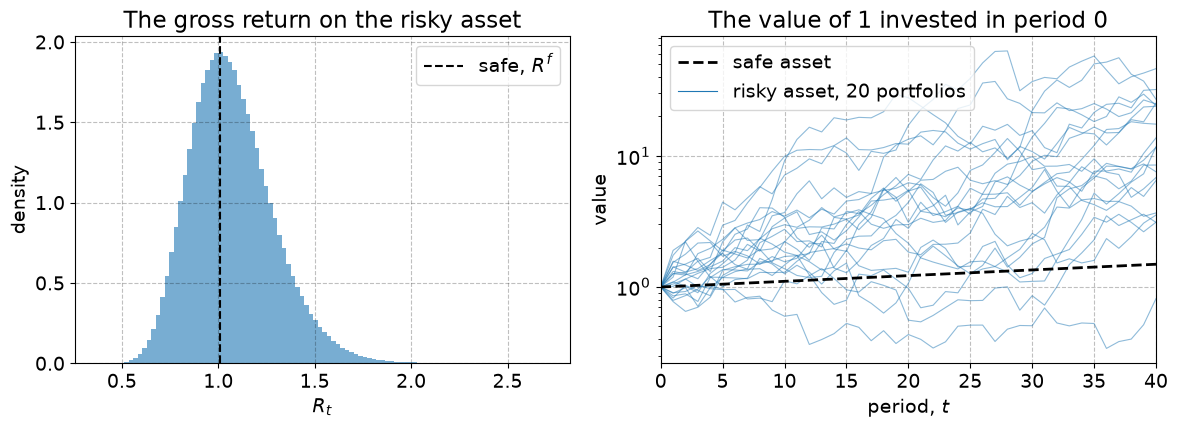

In [7]:
def plot_returns(model,R,n_show=20):

    par = model.par

    # a. the value of 1 invested in period 0, one period at a time
    V_risky = np.ones((n_show,par.T+1))
    for t in range(par.T):
        V_risky[:,t+1] = V_risky[:,t]*R[:n_show,t]

    V_safe = np.ones(par.T+1)
    for t in range(par.T):
        V_safe[t+1] = V_safe[t]*np.exp(par.r)

    fig = plt.figure(figsize=(12,4.5))

    # b. the distribution of the gross return
    ax = fig.add_subplot(1,2,1)
    ax.hist(R.reshape(par.N*par.T),bins=100,density=True,color=colors[0],alpha=0.60)
    ax.axvline(np.exp(par.r),ls='--',lw=1.5,color='black',label='safe, $R^f$')
    ax.set_title('The gross return on the risky asset')
    ax.set_xlabel('$R_t$')
    ax.set_ylabel('density')
    ax.legend()

    # c. the value of 1 invested in period 0
    ax = fig.add_subplot(1,2,2)
    ax.plot(V_risky.T,lw=0.8,color=colors[0],alpha=0.50)
    ax.plot(V_safe,ls='--',lw=2,color='black',label='safe asset')
    ax.plot([],[],lw=0.8,color=colors[0],label=f'risky asset, {n_show} portfolios')
    ax.set_yscale('log')
    ax.set_title('The value of 1 invested in period 0')
    ax.set_xlabel('period, $t$')
    ax.set_ylabel('value')
    ax.set_xlim(0,par.T)
    ax.legend()

    fig.tight_layout()
    plt.show()

plot_returns(model,R)

The moments of the log return. With $N \times T = 2{,}000{,}000$ draws the
sample mean of $\log R_t$ is 0.0500 and the sample standard deviation is
0.2000, matching $\mu = 0.05$ and $\sigma = 0.20$ to four decimals. This is
what we should expect: $\log R_t = \mu + \sigma \varepsilon_t$ is normal by
construction, and with this many draws the sampling error is small.

The mean of $R_t$ is 1.0725. This is not $\exp(\mu) = 1.0513$, but
$\exp(\mu + \tfrac{1}{2}\sigma^2) = 1.0725$. The gap arises because the
exponential function is convex, so a symmetric spread in $\log R_t$ becomes a
right-skewed distribution in $R_t$, and the mean is pulled above the median.
The larger $\sigma$ is, the larger the gap.

The safe asset gives $\exp(r) = 1.0101$ in every period. In expectation the
risky asset therefore pays about 6 percentage points more per period, but it is
far from a sure thing: 42 percent of the drawn returns fall below the safe
return.

Panel i) of the figure shows the right-skewed shape described above, with the
safe return marked for comparison. In panel ii) the safe asset is a straight
line on the logarithmic scale, since it grows by the same factor every period.
The risky paths fan out around it, and the spread widens with $t$ because the
variance of the log value after $t$ periods is $\sigma^2 t$. Of the 20 paths
shown, 19 end above the safe asset and one ends below its starting value, which
is the risk the investor is taking on.